# 07 — Final Results, Correlation Analysis and Report Figures

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

TABLES = ROOT / "results" / "tables"
FIG = ROOT / "results" / "figures"
PROCESSED = ROOT / "data" / "processed"
FIG.mkdir(parents=True, exist_ok=True)

metrics = pd.read_csv(TABLES / "06_FINAL_common_sample_metrics.csv")
pred = pd.read_csv(TABLES / "06_FINAL_common_sample_predictions.csv", parse_dates=["Date"])

primary = (
    metrics[metrics["Horizon"].eq(21)]
    .sort_values("QLIKE")
    .reset_index(drop=True)
)
primary.to_csv(TABLES / "07_primary_21d_report_table.csv", index=False)

display(primary[
    ["Model","N","QLIKE","MAE","RMSE","MASE","Correlation","Bias","Variability_Ratio"]
])


,Model,N,QLIKE,MAE,RMSE,MASE,Correlation,Bias,Variability_Ratio
0,Stock_Level_ML_Aggregated,414,0.184792,0.053823,0.071646,0.789663,0.471149,-0.009237,0.639931
1,GARCH_11,414,0.204736,0.067615,0.090490,0.992000,0.371461,0.032927,0.893995
2,HAR_RV,414,0.204919,0.063859,0.084854,0.936903,0.391657,0.018146,0.892840
3,EWMA_094,414,0.244545,0.061370,0.082403,0.900380,0.395307,-0.002731,0.885193
4,ARIMA_101,414,0.308274,0.067957,0.090318,0.997023,0.366430,-0.003941,1.026066
5,Selected_ML_WalkForward,414,0.308699,0.065125,0.084995,0.955471,0.290878,-0.034568,0.509771
6,Historical_Matched,414,0.313652,0.068160,0.090534,1.000000,0.364574,-0.004600,1.027225
7,Persistence_21D,414,0.313652,0.068160,0.090534,1.000000,0.364574,-0.004600,1.027225
8,Naive_h_Target_Lag,414,0.313652,0.068160,0.090534,1.000000,0.364574,-0.004600,1.027225


## 1. Primary 21-day forecast paths

In [2]:
z = pred[pred["Horizon"].eq(21)].copy()

show = [
    "Actual",
    "Stock_Level_ML_Aggregated",
    "Selected_ML_WalkForward",
    "HAR_RV",
    "GARCH_11",
    "EWMA_094",
]

fig, ax = plt.subplots(figsize=(13, 6))
for name in show:
    ax.plot(z["Date"], z[name], label=name, linewidth=2 if name=="Actual" else 1.25)

ax.set_title("21-Day Realised Volatility: Actual and Out-of-Sample Forecasts")
ax.set_xlabel("Date")
ax.set_ylabel("Annualised volatility")
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(FIG / "07_21d_actual_vs_forecasts.png", dpi=200, bbox_inches="tight")
plt.show()


### Focused primary-horizon comparison: actual vs best ML and best conventional benchmark

Best 21-day ML by QLIKE: Stock_Level_ML_Aggregated (0.1848)
Best 21-day conventional model by QLIKE: GARCH_11 (0.2047)


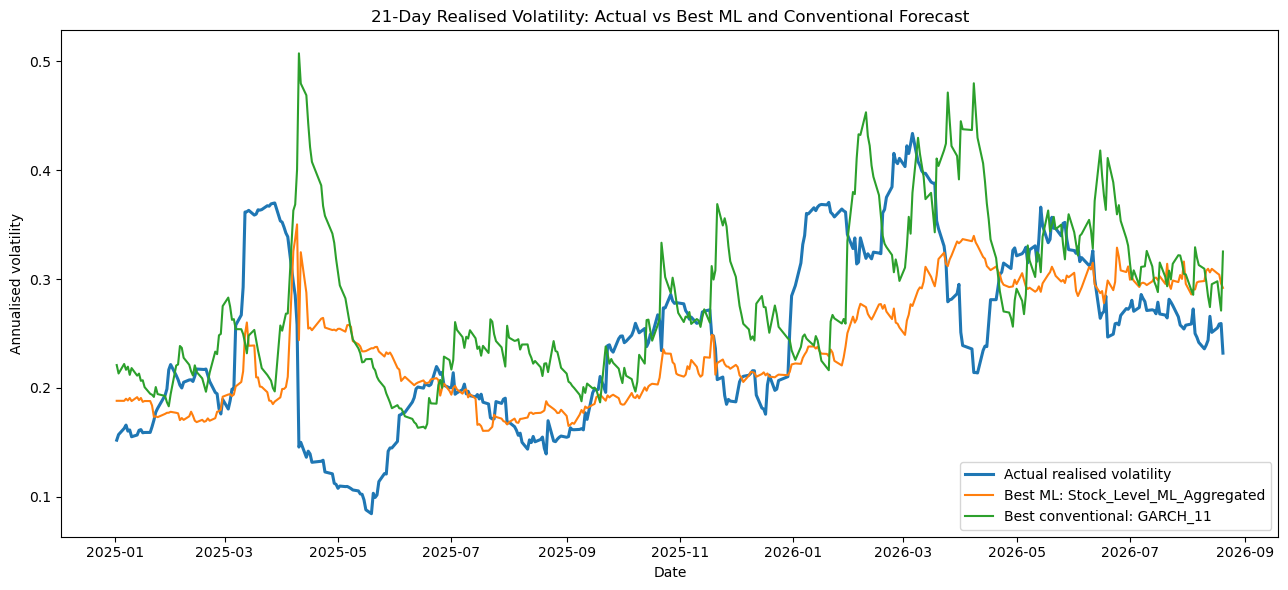

In [3]:

ml_candidates = [
    "Selected_ML_WalkForward",
    "Stock_Level_ML_Aggregated",
]

conventional_candidates = [
    "Naive_h_Target_Lag",
    "Historical_Matched",
    "Persistence_21D",
    "EWMA_094",
    "HAR_RV",
    "ARIMA_101",
    "GARCH_11",
]

m21 = metrics[metrics["Horizon"].eq(21)].copy()

ml_available = m21[m21["Model"].isin(ml_candidates)].dropna(subset=["QLIKE"])
conv_available = m21[m21["Model"].isin(conventional_candidates)].dropna(subset=["QLIKE"])

if ml_available.empty or conv_available.empty:
    raise ValueError("Could not identify both ML and conventional candidates for the 21-day comparison.")

best_ml = ml_available.sort_values("QLIKE").iloc[0]["Model"]
best_conv = conv_available.sort_values("QLIKE").iloc[0]["Model"]

best_ml_qlike = float(
    ml_available.loc[ml_available["Model"].eq(best_ml), "QLIKE"].iloc[0]
)
best_conv_qlike = float(
    conv_available.loc[conv_available["Model"].eq(best_conv), "QLIKE"].iloc[0]
)

print(f"Best 21-day ML by QLIKE: {best_ml} ({best_ml_qlike:.4f})")
print(f"Best 21-day conventional model by QLIKE: {best_conv} ({best_conv_qlike:.4f})")

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    z["Date"],
    z["Actual"],
    label="Actual realised volatility",
    linewidth=2.2
)

ax.plot(
    z["Date"],
    z[best_ml],
    label=f"Best ML: {best_ml}",
    linewidth=1.5
)

ax.plot(
    z["Date"],
    z[best_conv],
    label=f"Best conventional: {best_conv}",
    linewidth=1.5
)

ax.set_title(
    "21-Day Realised Volatility: Actual vs Best ML and Conventional Forecast"
)
ax.set_xlabel("Date")
ax.set_ylabel("Annualised volatility")
ax.legend()

fig.tight_layout()
fig.savefig(
    FIG / "07_21d_actual_vs_best_ml_and_conventional.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


## 2. Forecast-versus-realised correlation

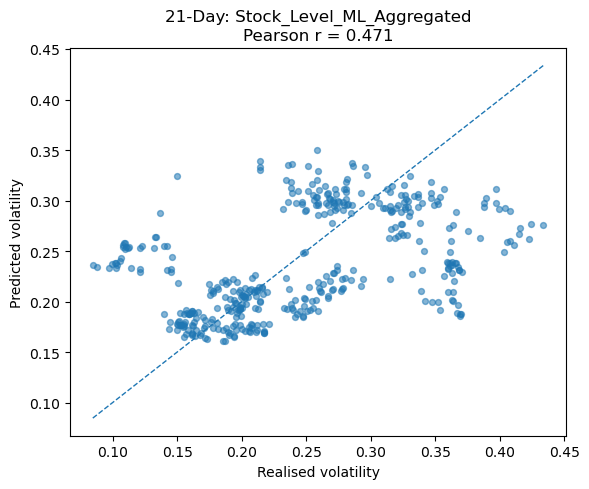

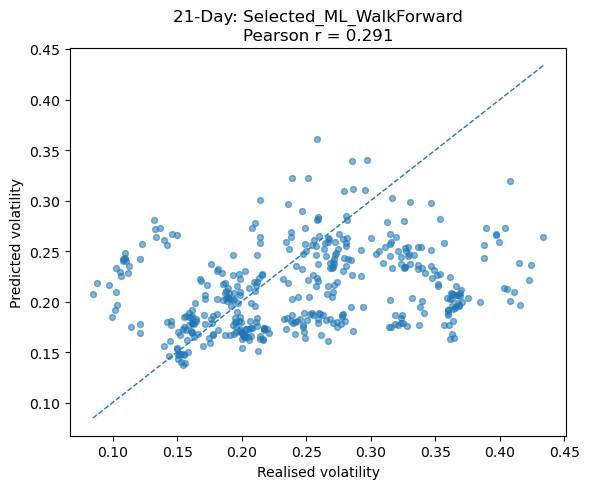

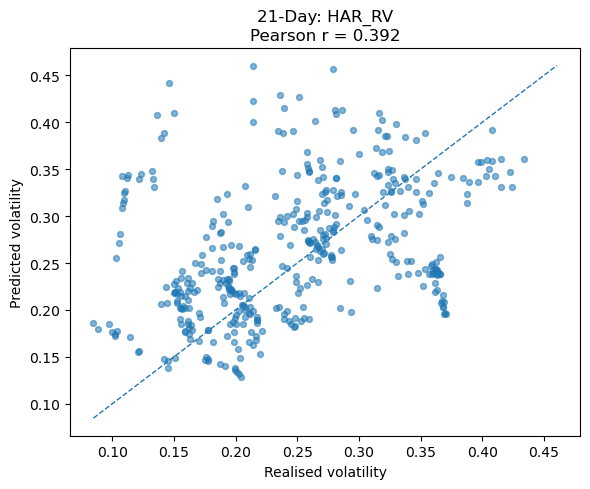

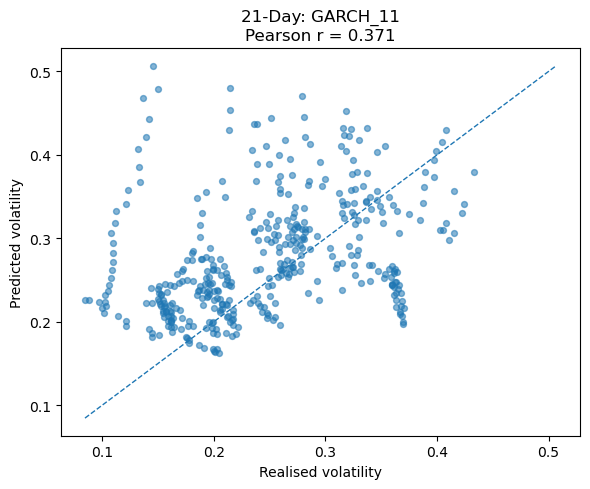

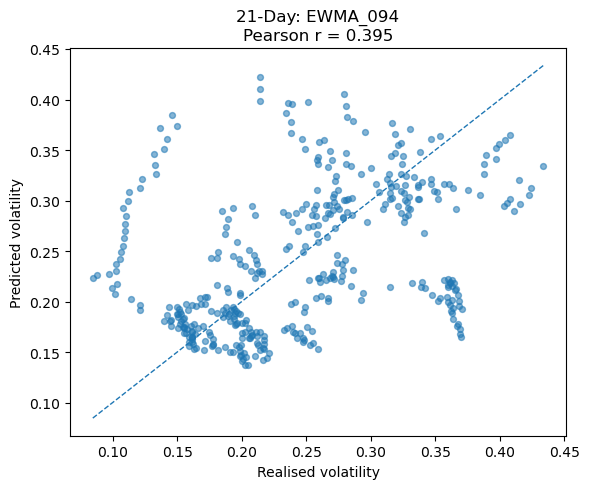

In [4]:
scatter_models = [
    "Stock_Level_ML_Aggregated",
    "Selected_ML_WalkForward",
    "HAR_RV",
    "GARCH_11",
    "EWMA_094",
]

for name in scatter_models:
    x = z["Actual"].to_numpy(float)
    y = z[name].to_numpy(float)
    r = np.corrcoef(x, y)[0, 1]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(x, y, s=18, alpha=0.55)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], "--", linewidth=1)
    ax.set_title(f"21-Day: {name}\nPearson r = {r:.3f}")
    ax.set_xlabel("Realised volatility")
    ax.set_ylabel("Predicted volatility")
    fig.tight_layout()
    fig.savefig(FIG / f"07_scatter_{name}.png", dpi=200, bbox_inches="tight")
    plt.show()


## 3. Accuracy across horizons

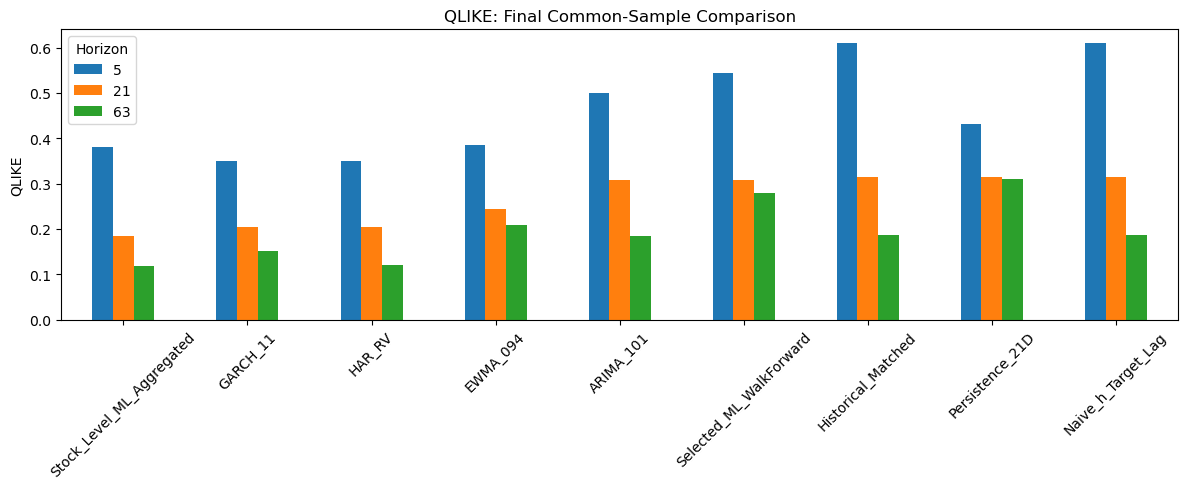

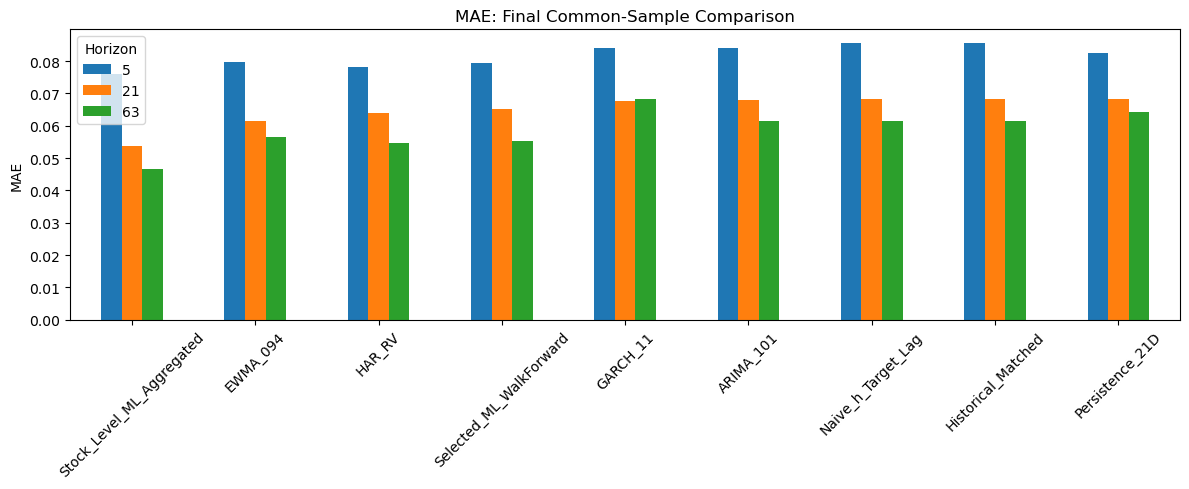

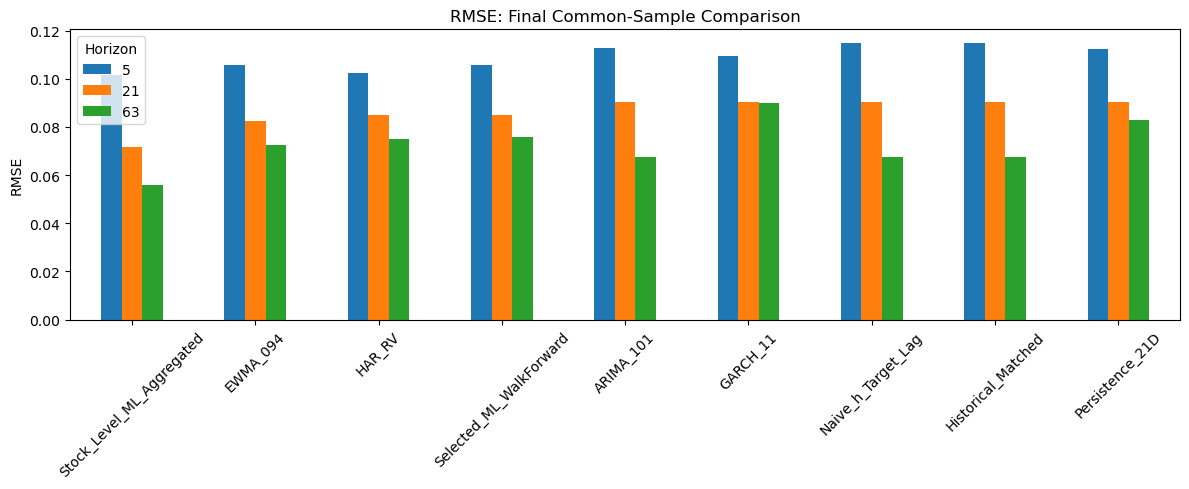

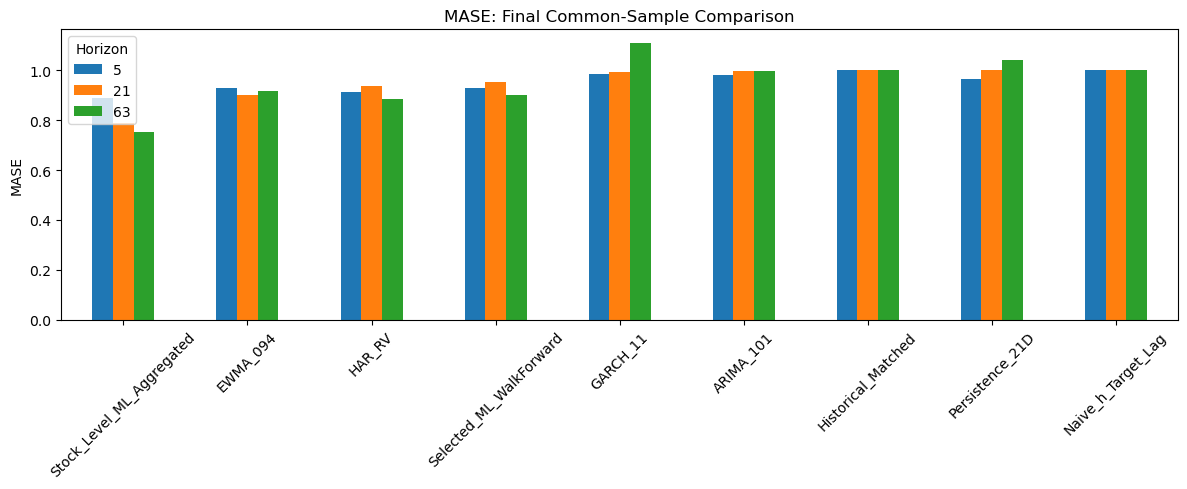

In [5]:
for metric in ["QLIKE", "MAE", "RMSE", "MASE"]:
    q = metrics.pivot(index="Model", columns="Horizon", values=metric)
    order = (
        metrics[metrics["Horizon"].eq(21)]
        .sort_values(metric)["Model"]
        .tolist()
    )
    q = q.reindex(order)

    fig, ax = plt.subplots(figsize=(12, 5))
    q.plot(kind="bar", ax=ax)
    ax.set_title(f"{metric}: Final Common-Sample Comparison")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(FIG / f"07_metric_{metric.lower()}.png", dpi=200, bbox_inches="tight")
    plt.show()


## 4. Correlation, bias and forecast variability

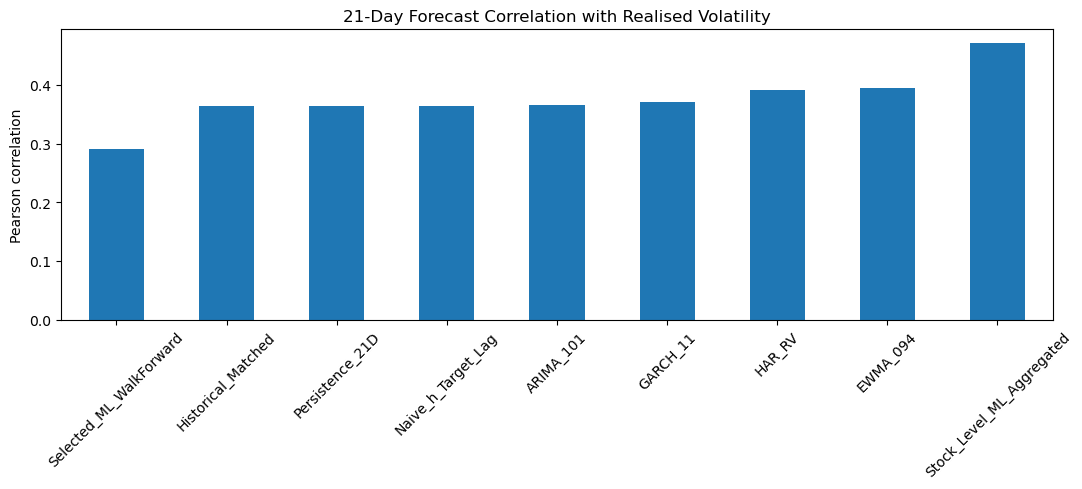

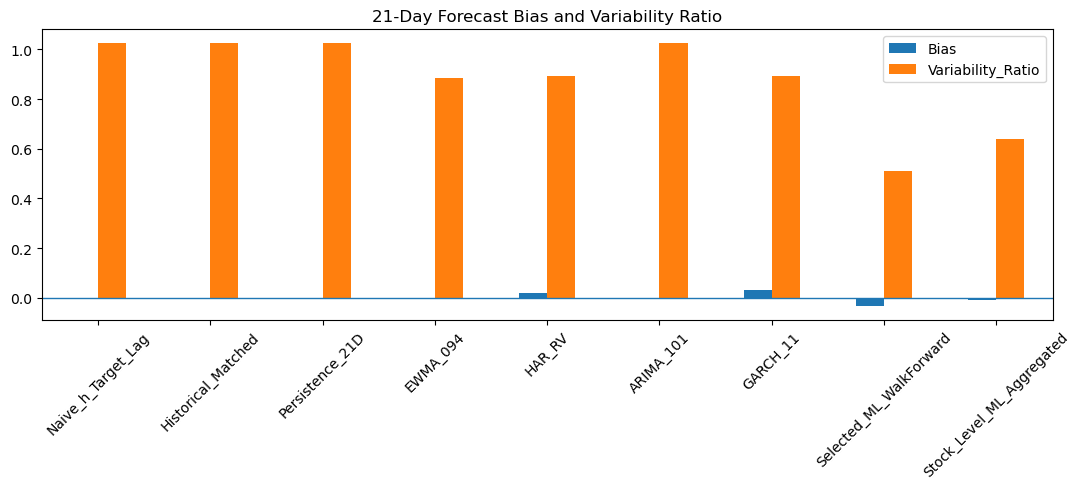

In [6]:
p21 = metrics[metrics["Horizon"].eq(21)].copy()

fig, ax = plt.subplots(figsize=(11, 5))
p21.sort_values("Correlation").plot(
    x="Model", y="Correlation", kind="bar", legend=False, ax=ax
)
ax.set_title("21-Day Forecast Correlation with Realised Volatility")
ax.set_xlabel("")
ax.set_ylabel("Pearson correlation")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIG / "07_21d_forecast_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
p21.set_index("Model")[["Bias","Variability_Ratio"]].plot(kind="bar", ax=ax)
ax.axhline(0, linewidth=1)
ax.set_title("21-Day Forecast Bias and Variability Ratio")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIG / "07_21d_bias_variability.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Direct sector ML versus pooled stock-level ML

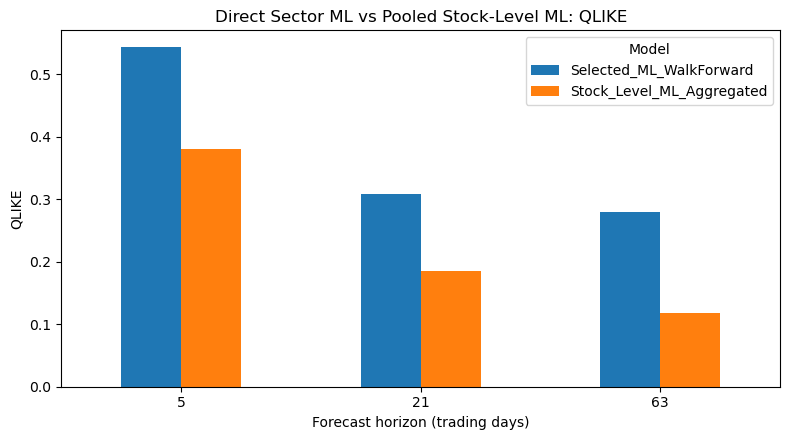

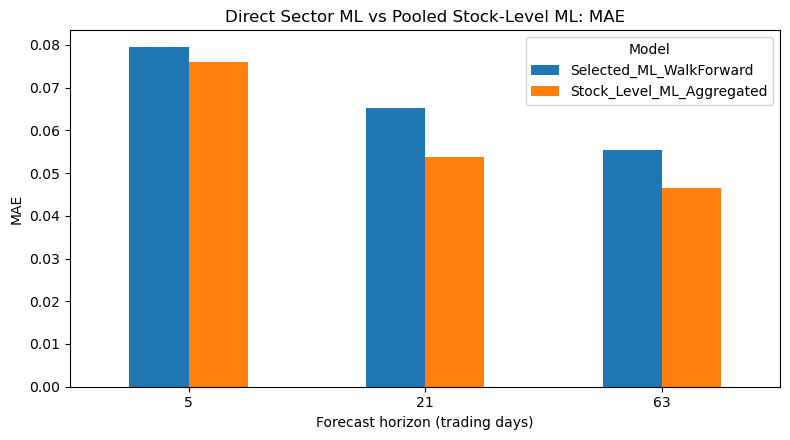

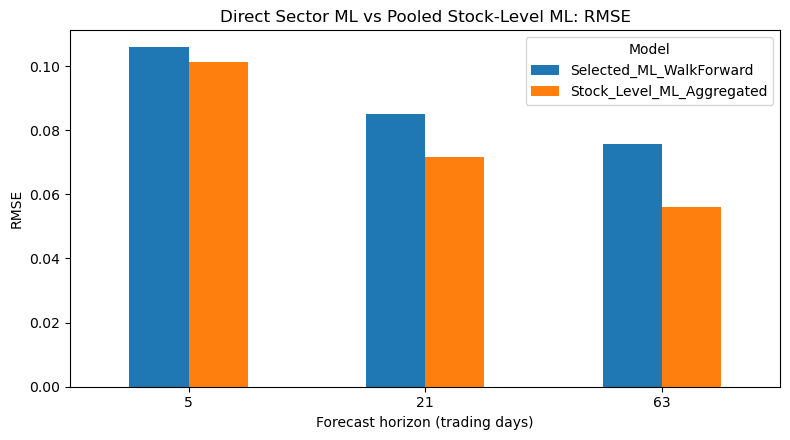

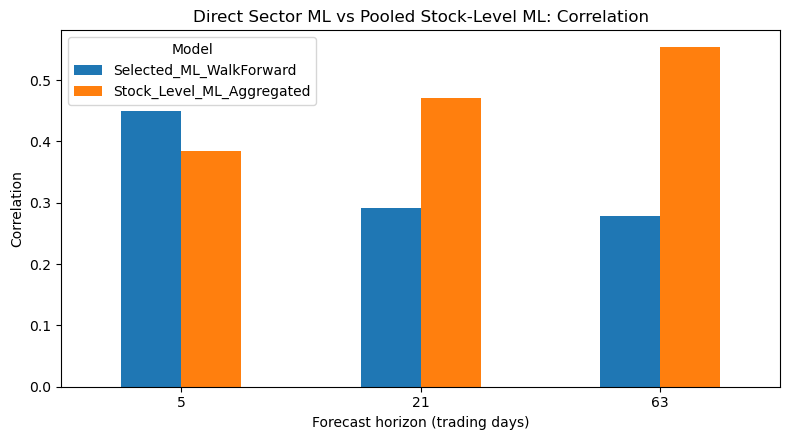

In [7]:
ml_compare = metrics[
    metrics["Model"].isin(["Selected_ML_WalkForward","Stock_Level_ML_Aggregated"])
].copy()

for metric in ["QLIKE","MAE","RMSE","Correlation"]:
    q = ml_compare.pivot(index="Horizon", columns="Model", values=metric)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    q.plot(kind="bar", ax=ax)
    ax.set_title(f"Direct Sector ML vs Pooled Stock-Level ML: {metric}")
    ax.set_xlabel("Forecast horizon (trading days)")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=0)
    fig.tight_layout()
    fig.savefig(FIG / f"07_direct_vs_stock_{metric.lower()}.png", dpi=200, bbox_inches="tight")
    plt.show()


## 6. Individual-stock predictive diagnostics

,Horizon,N,QLIKE,MAE,RMSE,Correlation,Bias,Actual_Std,Prediction_Std,Variability_Ratio
0,5,21361,2.468688,0.188058,0.283660,0.513336,0.019873,0.325077,0.214236,0.659032
1,21,20213,0.396688,0.136340,0.202333,0.628254,0.003837,0.253654,0.203869,0.803729
2,63,17446,0.213253,0.111220,0.156517,0.695076,-0.016123,0.212013,0.179083,0.844678


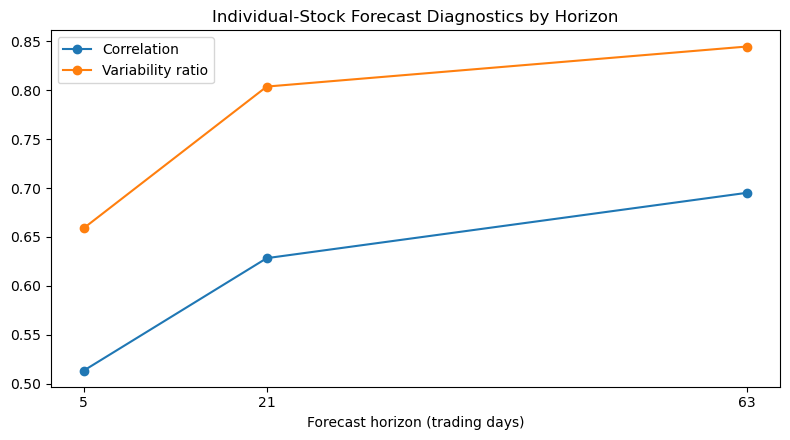

In [8]:
stock_metrics_path = TABLES / "05_stock_level_test_metrics.csv"
stock_metrics = pd.read_csv(stock_metrics_path)

if (stock_metrics["N"] <= 0).any():
    raise ValueError(
        "05_stock_level_test_metrics.csv still contains N=0. "
        "Rerun the corrected final diagnostics cell in Notebook 05 and save the CSV."
    )

display(stock_metrics)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(stock_metrics["Horizon"], stock_metrics["Correlation"], marker="o", label="Correlation")
ax.plot(stock_metrics["Horizon"], stock_metrics["Variability_Ratio"], marker="o", label="Variability ratio")
ax.set_title("Individual-Stock Forecast Diagnostics by Horizon")
ax.set_xlabel("Forecast horizon (trading days)")
ax.set_xticks(stock_metrics["Horizon"])
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "07_stock_level_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Feature–target correlations for the primary horizon

In [9]:
d = pd.read_parquet(PROCESSED / "volatility_features_h21.parquet").copy()
target = "Target_RV_21"

numeric = [
    c for c in d.select_dtypes(include=[np.number]).columns
    if c != "Sector_Return" and not c.startswith("Target_RV_")
]

corr = (
    d[[target] + numeric]
    .corr(numeric_only=True)[target]
    .drop(target)
    .dropna()
)

top_names = corr.abs().sort_values(ascending=False).head(20).index
top_corr = corr.loc[top_names].sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_corr.index, top_corr.values)
ax.axvline(0, linewidth=1)
ax.set_title("Top 20 Correlations with Future 21-Day Realised Volatility")
ax.set_xlabel("Pearson correlation")
fig.tight_layout()
fig.savefig(FIG / "07_21d_target_feature_correlations.png", dpi=200, bbox_inches="tight")
plt.show()


## 8. Primary feature correlation matrix

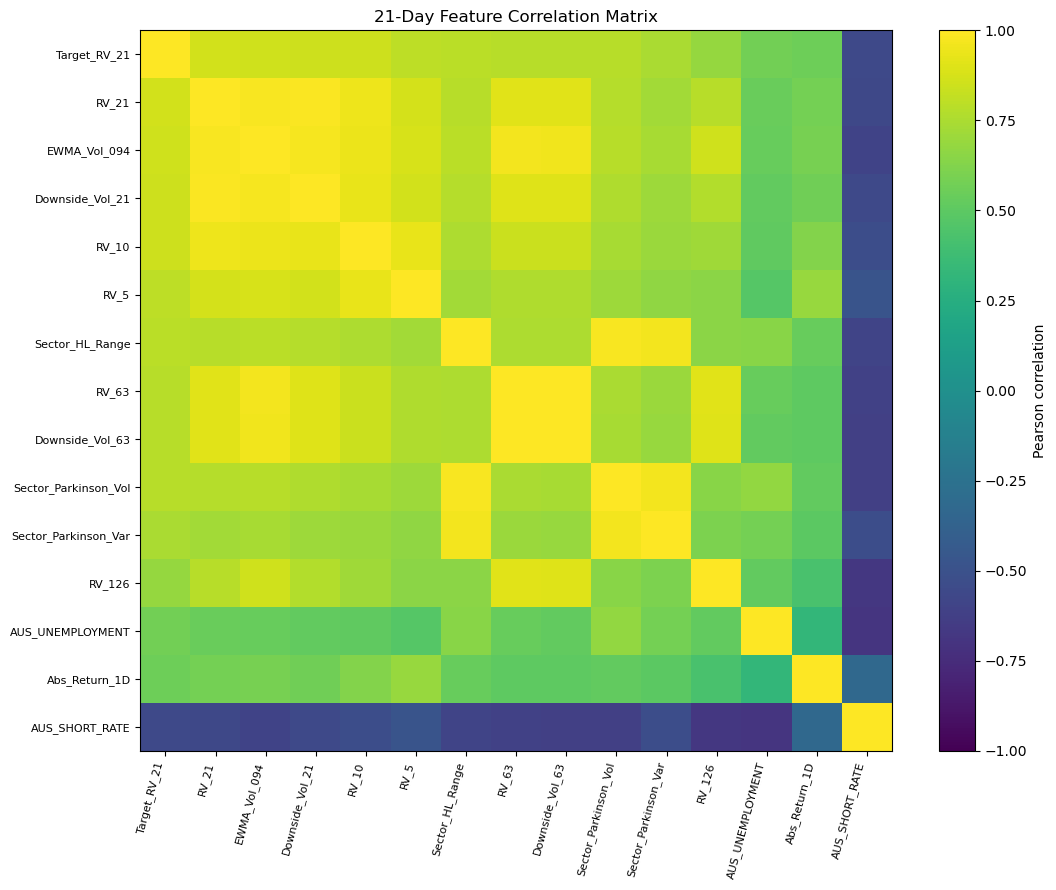

In [10]:
heat_cols = [target] + corr.abs().sort_values(ascending=False).head(14).index.tolist()
cm = d[heat_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm.to_numpy(), aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(heat_cols)))
ax.set_xticklabels(heat_cols, rotation=75, ha="right", fontsize=8)
ax.set_yticks(range(len(heat_cols)))
ax.set_yticklabels(heat_cols, fontsize=8)
ax.set_title("21-Day Feature Correlation Matrix")
fig.colorbar(im, ax=ax, label="Pearson correlation")
fig.tight_layout()
fig.savefig(FIG / "07_21d_feature_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Validation-only permutation importance

,Feature,QLIKE_Increase_Mean,QLIKE_Increase_SD
0,VIX_Level,0.007881,0.001711
1,Drawdown_63,0.006369,0.000804
2,RV21_Change_5D,0.003166,0.000867
3,AUS_UNEMPLOYMENT,0.002559,0.000294
4,VIX_Return_21D,0.002119,0.001112


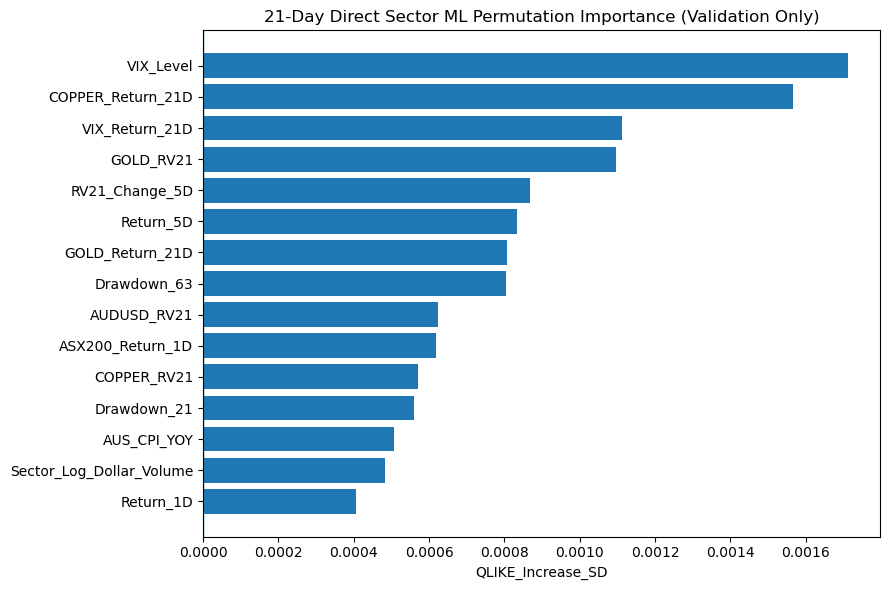

In [11]:
imp_path = TABLES / "04_permutation_importance_21d.csv"

if imp_path.exists():
    imp = pd.read_csv(imp_path)
    display(imp.head())

    feature_col = "Feature" if "Feature" in imp.columns else imp.columns[0]
    numeric_cols = [
        c for c in imp.select_dtypes(include=[np.number]).columns
        if c.lower() != "horizon"
    ]

    if numeric_cols:
        # Prefer a clearly named importance column where available.
        candidates = [c for c in numeric_cols if "importance" in c.lower()]
        value_col = candidates[0] if candidates else numeric_cols[-1]

        q = imp.sort_values(value_col, ascending=False).head(15).sort_values(value_col)

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(q[feature_col], q[value_col])
        ax.axvline(0, linewidth=1)
        ax.set_title("21-Day Direct Sector ML Permutation Importance (Validation Only)")
        ax.set_xlabel(value_col)
        fig.tight_layout()
        fig.savefig(FIG / "07_21d_permutation_importance.png", dpi=200, bbox_inches="tight")
        plt.show()
else:
    print("Permutation-importance file not found. Run Notebook 04 before this report notebook.")


21-day ML directional accuracy: 48.18%


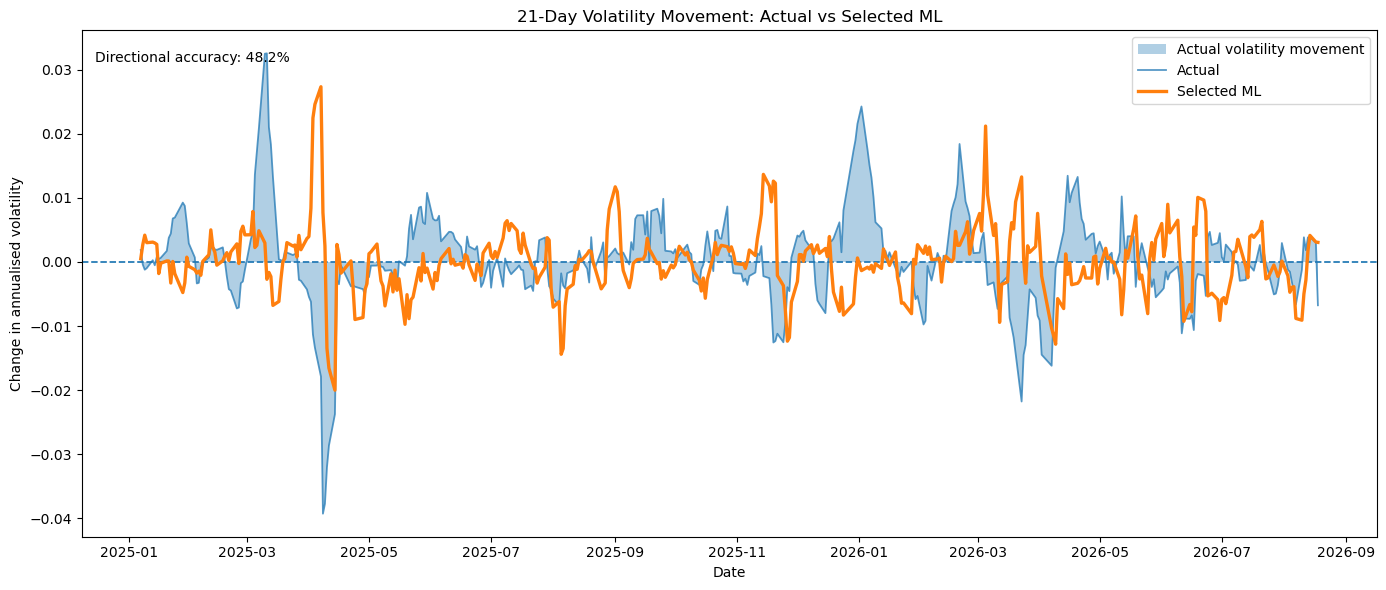

In [15]:
z = pred[
    pred["Horizon"].eq(21)
].copy()

z = z.sort_values("Date").copy()

z["Actual_Change"] = z["Actual"].diff()

z["ML_Change"] = z["Selected_ML_WalkForward"].diff()

z["Actual_Direction"] = np.sign(z["Actual_Change"])
z["ML_Direction"] = np.sign(z["ML_Change"])


plot_z = z.dropna(
    subset=[
        "Actual_Change",
        "ML_Change"
    ]
).copy()

plot_z["Direction_Correct"] = (
    plot_z["Actual_Direction"]
    == plot_z["ML_Direction"]
)

directional_accuracy = (
    plot_z["Direction_Correct"].mean()
)

print(
    f"21-day ML directional accuracy: "
    f"{directional_accuracy:.2%}"
)

VISUAL_WINDOW = 5

plot_z["Actual_Visual"] = (
    plot_z["Actual_Change"]
    .rolling(
        VISUAL_WINDOW,
        center=True
    )
    .mean()
)

plot_z["ML_Visual"] = (
    plot_z["ML_Change"]
    .rolling(
        VISUAL_WINDOW,
        center=True
    )
    .mean()
)


fig, ax = plt.subplots(
    figsize=(14, 6)
)


# Zero baseline
ax.axhline(
    0,
    linewidth=1.25,
    linestyle="--"
)

ax.fill_between(
    plot_z["Date"],
    0,
    plot_z["Actual_Visual"],
    alpha=0.35,
    label="Actual volatility movement"
)

ax.plot(
    plot_z["Date"],
    plot_z["Actual_Visual"],
    linewidth=1.3,
    alpha=0.75,
    label="Actual"
)


ax.plot(
    plot_z["Date"],
    plot_z["ML_Visual"],
    linewidth=2.4,
    label="Selected ML"
)

ax.set_title(
    "21-Day Volatility Movement: "
    "Actual vs Selected ML"
)

ax.text(
    0.01,
    0.96,
    (
        f"Directional accuracy: "
        f"{directional_accuracy:.1%}"
    ),
    transform=ax.transAxes,
    va="top",
    fontsize=10
)

ax.set_xlabel("Date")

ax.set_ylabel(
    "Change in annualised volatility"
)

ax.legend(
    loc="upper right"
)

fig.tight_layout()

fig.savefig(
    FIG / "07_21d_volatility_movement_clear.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 10. Final output audit

In [ ]:
required_figures = [
    "07_21d_actual_vs_forecasts.png",
    "07_21d_actual_vs_best_ml_and_conventional.png",
    "07_21d_forecast_correlation.png",
    "07_21d_bias_variability.png",
    "07_21d_target_feature_correlations.png",
    "07_21d_feature_correlation_heatmap.png",
    "07_direct_vs_stock_qlike.png",
]

missing = [f for f in required_figures if not (FIG / f).exists()]
assert not missing, f"Missing report figures: {missing}"

assert not primary.empty
assert (primary["N"] > 0).all()
assert np.isfinite(primary[["QLIKE","MAE","RMSE"]].to_numpy()).all()

print("Final results tables and report figures generated successfully.")
